### EDA
train.csv  
   ↓  
학생 특성 X + 실제 health_condition y  
   ↓  
모델 학습  
   ↓  
test.csv의 학생들에게 health_condition 예측  
   ↓  
sample_submission.csv의 health_condition 부분을  
모델의 예측값으로 교체  
   ↓  
submission.csv 제출  

In [25]:
import os
from pathlib import Path

if Path.cwd().name == "가이드프로젝트":
    os.chdir(Path.cwd().parent)

print(os.getcwd())

c:\Users\나현서\OneDrive\Desktop\26-2 DScover


In [26]:
import pandas as pd
import numpy as np

train = pd.read_csv("가이드프로젝트/train.csv")
test = pd.read_csv("가이드프로젝트/test.csv")
submission = pd.read_csv("가이드프로젝트/sample_submission.csv")

In [27]:
print("train shape:", train.shape)
print("test shape:", test.shape)
print("submission shape:", submission.shape)

train shape: (690088, 15)
test shape: (295753, 14)
submission shape: (295753, 2)


In [28]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [29]:
# 평가지표 비율 확인
train["health_condition"].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [30]:
train["health_condition"].value_counts(normalize=True)

health_condition
at-risk      0.858675
unhealthy    0.083647
fit          0.057678
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribution of Health Condition'}, xlabel='health_condition'>

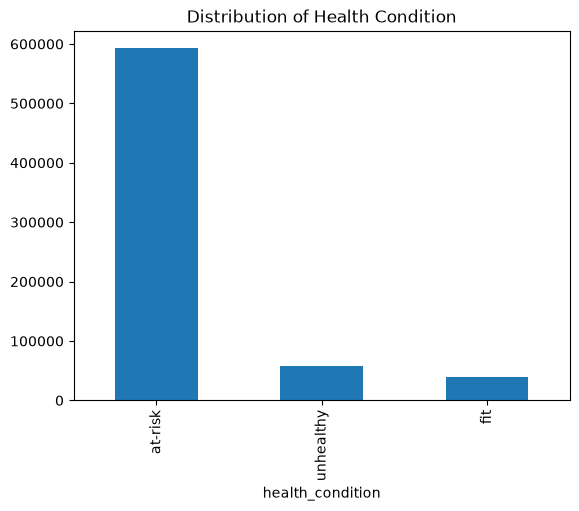

In [31]:
train["health_condition"].value_counts().plot(
    kind="bar",
    title="Distribution of Health Condition"
)

health_condition 불균형이 매우 큼. 

In [32]:
# 항목별 결측치 확인
missing = pd.DataFrame({
    "missing_count": train.isnull().sum(),
    "missing_ratio": train.isnull().mean() * 100
})

missing.sort_values("missing_ratio", ascending=False)

,missing_count,missing_ratio
stress_level,82811,12.000064
sleep_duration,75999,11.012943
sleep_quality,58331,8.452690
calorie_expenditure,52853,7.658878
water_intake,43477,6.300211
physical_activity_level,36621,5.306715
smoking_alcohol,28582,4.141791
gender,21373,3.097141
step_count,13916,2.016554
bmi,13898,2.013946


In [33]:
# 범주형 변수 값 확인
categorical_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in categorical_cols:
    print(f"\n[{col}]")
    print(train[col].value_counts(dropna=False))


[diet_type]
diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

[stress_level]
stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

[sleep_quality]
sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

[physical_activity_level]
physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

[smoking_alcohol]
smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

[gender]
gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64


In [34]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,690088.0,345043.500000,199211.390620,0.0,172521.75,345043.50,517565.25,690087.00
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


In [35]:
#클래스별 결측률
feature_cols = train.columns.drop(["id", "health_condition"])

for col in feature_cols:
    print(f"\n[{col}]")
    print(
        train.groupby("health_condition")[col]
        .apply(lambda x: x.isna().mean() * 100)
        .round(2)
    )
#-> 특정 클래스가 결측이 특히 많다 이런건 없음.


[sleep_duration]
health_condition
at-risk      11.02
fit          10.94
unhealthy    10.97
Name: sleep_duration, dtype: float64

[heart_rate]
health_condition
at-risk      1.15
fit          1.09
unhealthy    1.00
Name: heart_rate, dtype: float64

[bmi]
health_condition
at-risk      2.08
fit          2.86
unhealthy    0.71
Name: bmi, dtype: float64

[calorie_expenditure]
health_condition
at-risk      7.65
fit          7.70
unhealthy    7.69
Name: calorie_expenditure, dtype: float64

[step_count]
health_condition
at-risk      2.02
fit          1.99
unhealthy    1.95
Name: step_count, dtype: float64

[exercise_duration]
health_condition
at-risk      0.99
fit          1.05
unhealthy    1.06
Name: exercise_duration, dtype: float64

[water_intake]
health_condition
at-risk      6.27
fit          6.34
unhealthy    6.54
Name: water_intake, dtype: float64

[diet_type]
health_condition
at-risk      1.01
fit          0.88
unhealthy    0.98
Name: diet_type, dtype: float64

[stress_level]
health_co

In [36]:
#클래스별 숫자형 변수 평균값
numeric_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

train.groupby("health_condition")[numeric_cols].mean().T

health_condition,at-risk,fit,unhealthy
sleep_duration,7.086467,7.954311,5.366118
heart_rate,75.100534,74.803742,75.256903
bmi,22.949591,21.828544,24.122660
calorie_expenditure,2214.943466,2363.992052,2245.420223
step_count,8406.705910,11651.307024,8670.234090
exercise_duration,37.964960,50.042381,39.044280
water_intake,2.189130,2.179176,2.188961


숫자형 변수의 클래스별 분포 상세 보기

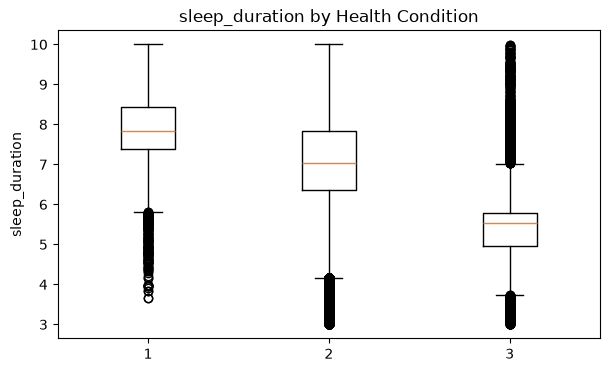

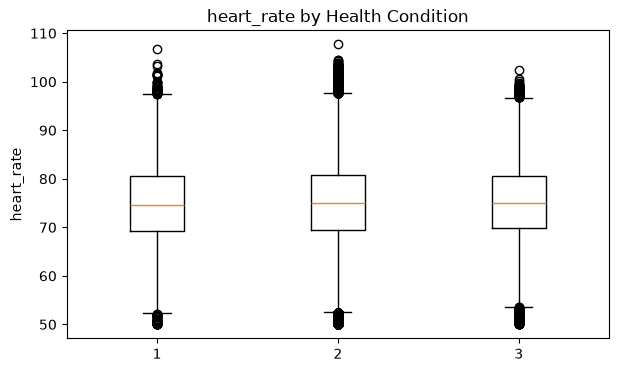

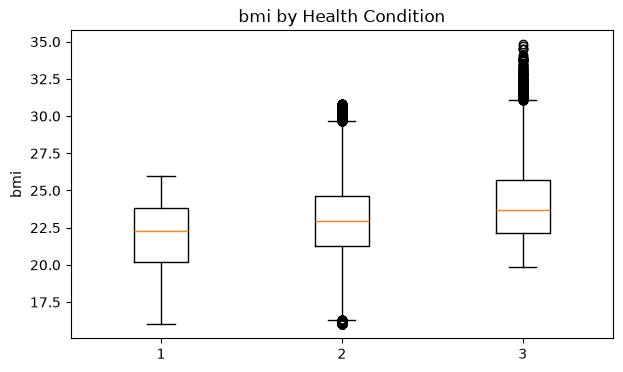

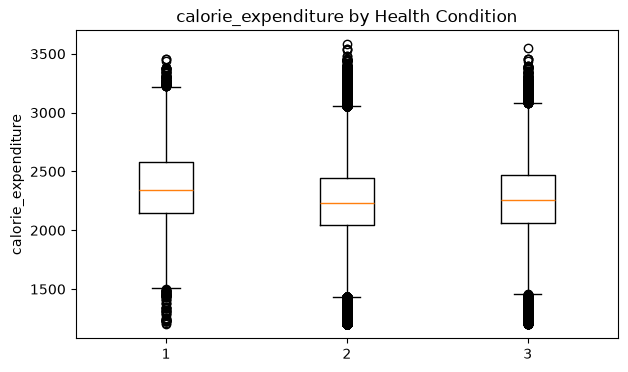

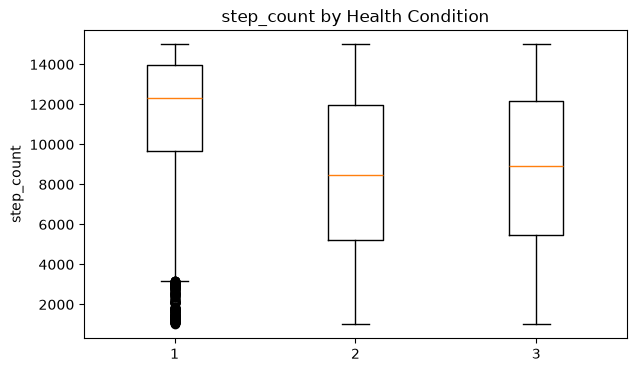

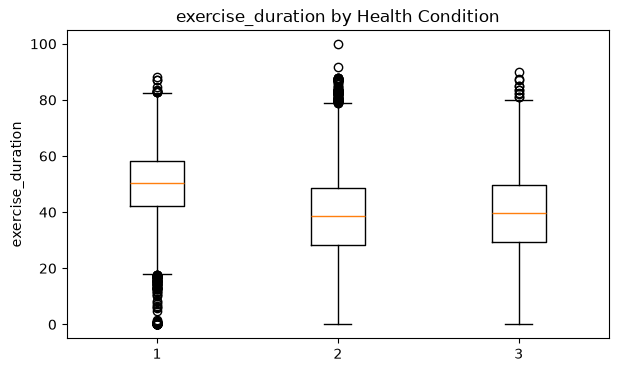

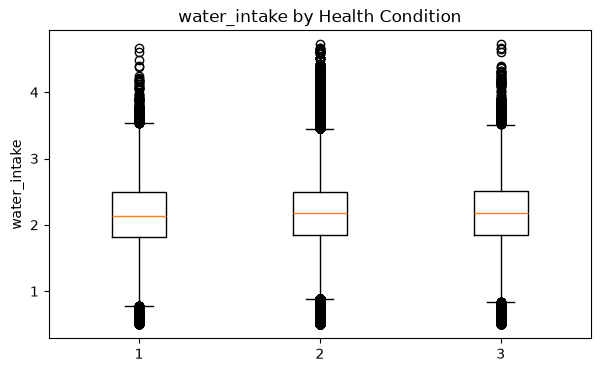

In [37]:
import matplotlib.pyplot as plt
#숫자형 변수별 boxplot
numeric_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

for col in numeric_cols:
    data = [
        train.loc[train["health_condition"] == "fit", col].dropna(),
        train.loc[train["health_condition"] == "at-risk", col].dropna(),
        train.loc[train["health_condition"] == "unhealthy", col].dropna()
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, label=["fit", "at-risk", "unhealthy"])
    plt.title(f"{col} by Health Condition")
    plt.ylabel(col)
    plt.show()

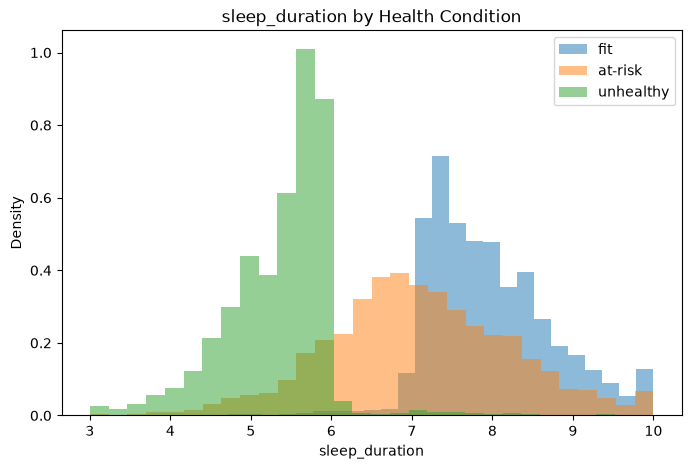

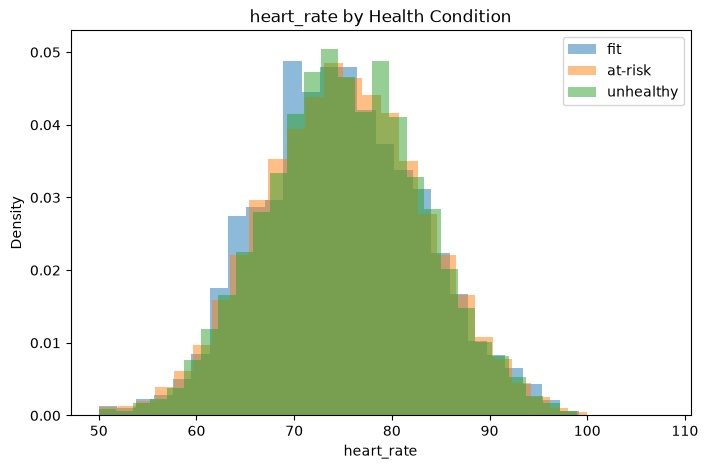

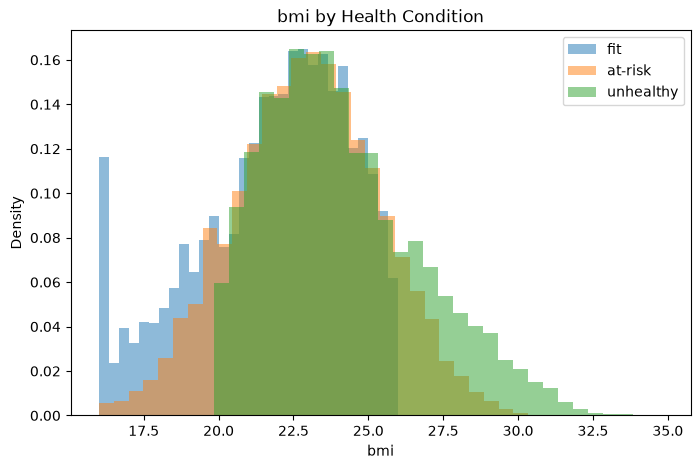

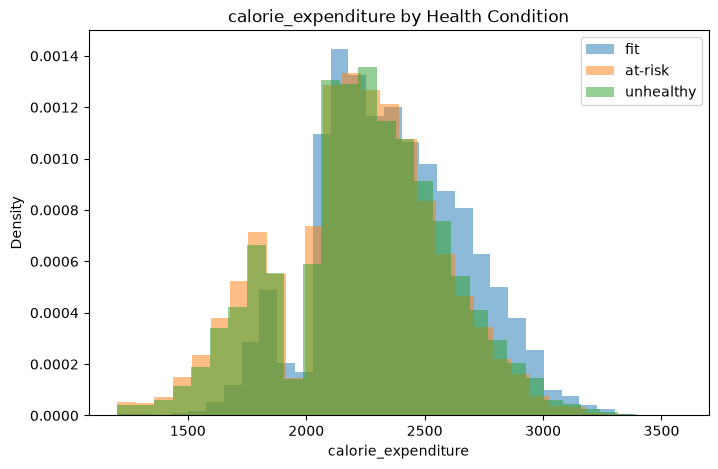

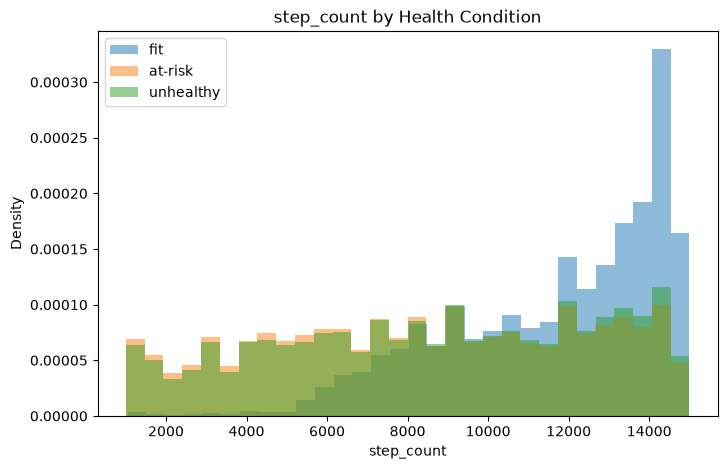

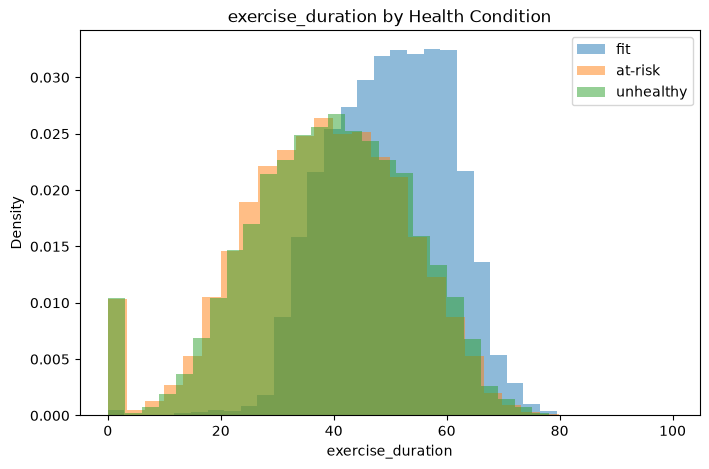

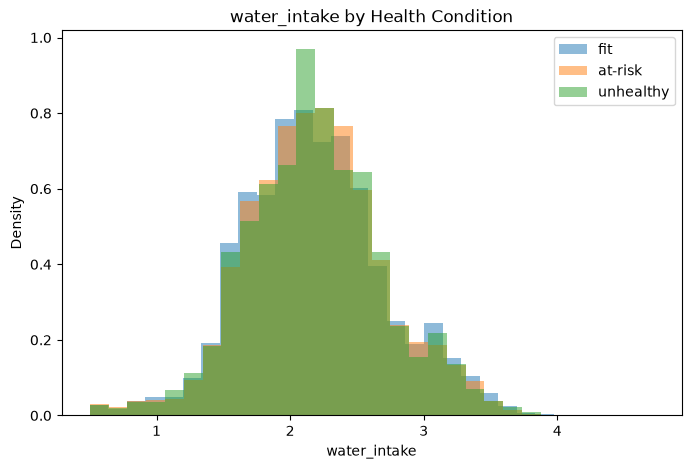

In [38]:
#숫자형 변수별 histogram
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    for condition in ["fit", "at-risk", "unhealthy"]:
        subset = train.loc[
            train["health_condition"] == condition,
            col
        ].dropna()

        plt.hist(
            subset,
            bins=30,
            alpha=0.5,
            density=True, #각 클래스 분포를 비율 기준으로 비교
            label=condition
        )

    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(f"{col} by Health Condition")
    plt.legend()
    plt.show()

범주형 변수의 클래스별 분포 상세 보기

In [39]:
categorical_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for col in categorical_cols:
    print(f"\n[{col}]")

    ratio = pd.crosstab(
        train[col],
        train["health_condition"],
        normalize="index"
    )

    display(ratio.round(3))


[diet_type]


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,0.851,0.061,0.087
non-veg,0.868,0.052,0.081
veg,0.857,0.060,0.083



[stress_level]


health_condition,at-risk,fit,unhealthy
stress_level,,,
high,0.718,0.004,0.279
low,0.797,0.201,0.003
medium,0.994,0.003,0.003



[sleep_quality]


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,0.743,0.172,0.085
moderate,0.911,0.003,0.085
sedentary,0.917,0.002,0.080



[smoking_alcohol]


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,0.867,0.079,0.055
occasional,0.859,0.058,0.084
yes,0.851,0.037,0.112



[gender]


health_condition,at-risk,fit,unhealthy
gender,,,
female,0.857,0.057,0.086
male,0.857,0.063,0.080
other,0.862,0.053,0.085


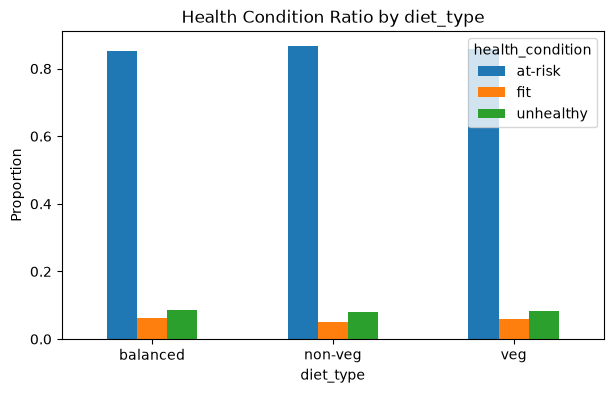

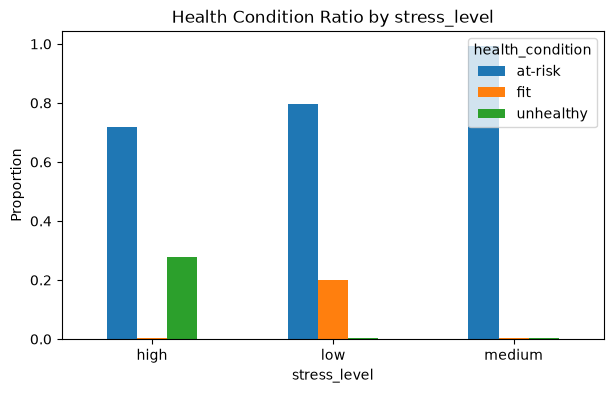

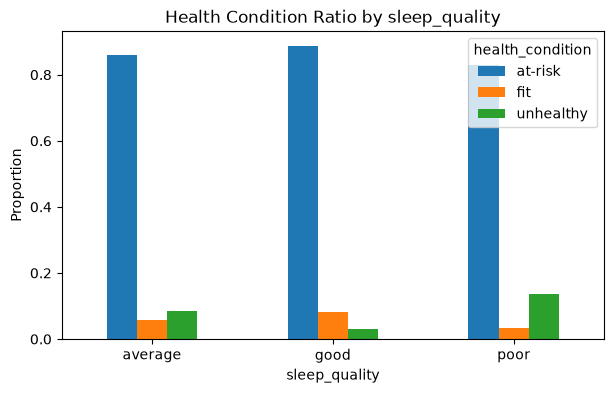

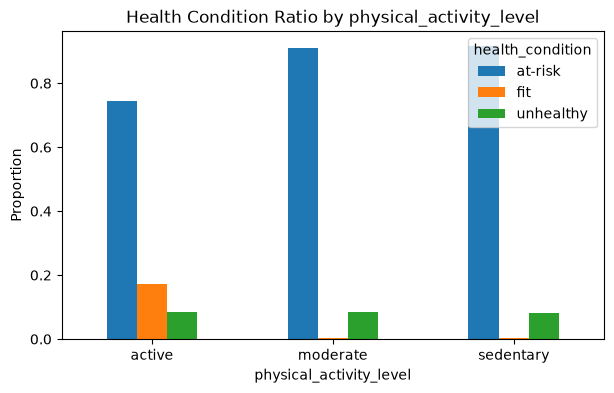

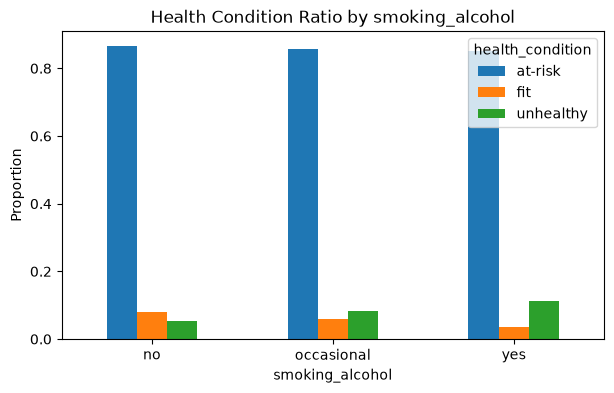

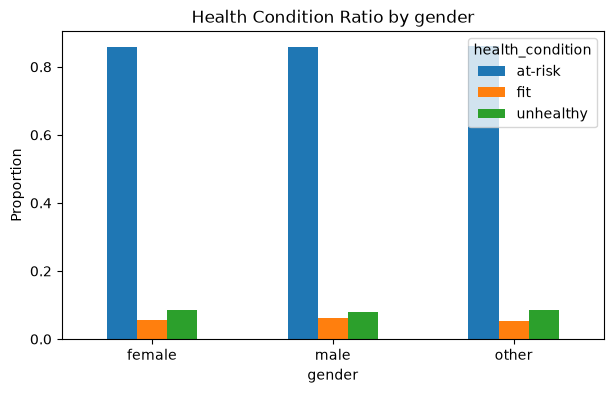

In [40]:
for col in categorical_cols:
    ratio = pd.crosstab(
        train[col],
        train["health_condition"],
        normalize="index"
    )

    ratio.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"Health Condition Ratio by {col}")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=0)
    plt.legend(title="health_condition")
    plt.show()

In [41]:
# 숫자형 변수 구간 나눠서 클래스 비율 보기 - 단변량으로 의미 있는 변수만
strong_numeric_cols = [
    "sleep_duration",
    "bmi",
    "step_count",
    "exercise_duration",
    "calorie_expenditure"
]
for col in strong_numeric_cols:
    temp = train[[col, "health_condition"]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[col],
        q=10,
        duplicates="drop"
    )

    ratio = pd.crosstab(
        temp["bin"],
        temp["health_condition"],
        normalize="index"
    )

    print(f"\n[{col}]")
    display(ratio.round(3))


[sleep_duration]


health_condition,at-risk,fit,unhealthy
bin,,,
"(2.999, 5.47]",0.604,0.002,0.394
"(5.47, 5.92]",0.626,0.002,0.372
"(5.92, 6.37]",0.951,0.003,0.046
"(6.37, 6.7]",0.996,0.003,0.001
"(6.7, 6.99]",0.991,0.007,0.002
"(6.99, 7.28]",0.910,0.086,0.004
"(7.28, 7.6]",0.868,0.129,0.003
"(7.6, 8.04]",0.883,0.114,0.002
"(8.04, 8.55]",0.888,0.110,0.002



[bmi]


health_condition,at-risk,fit,unhealthy
bin,,,
"(15.999, 19.79]",0.876,0.124,0.000
"(19.79, 20.91]",0.871,0.058,0.071
"(20.91, 21.68]",0.857,0.058,0.085
"(21.68, 22.37]",0.857,0.058,0.085
"(22.37, 22.99]",0.857,0.058,0.085
"(22.99, 23.6]",0.859,0.056,0.085
"(23.6, 24.27]",0.856,0.058,0.086
"(24.27, 25.05]",0.861,0.056,0.083
"(25.05, 26.17]",0.869,0.046,0.085



[step_count]


health_condition,at-risk,fit,unhealthy
bin,,,
"(1001.999, 3063.0]",0.917,0.002,0.081
"(3063.0, 4665.0]",0.914,0.003,0.083
"(4665.0, 6117.0]",0.906,0.011,0.083
"(6117.0, 7478.0]",0.882,0.034,0.084
"(7478.0, 8856.0]",0.864,0.053,0.083
"(8856.0, 10115.0]",0.857,0.059,0.084
"(10115.0, 11540.0]",0.846,0.069,0.085
"(11540.0, 12704.0]",0.834,0.082,0.084
"(12704.0, 13861.0]",0.810,0.103,0.087



[exercise_duration]


health_condition,at-risk,fit,unhealthy
bin,,,
"(-0.001, 20.4]",0.918,0.003,0.080
"(20.4, 26.7]",0.917,0.002,0.081
"(26.7, 31.5]",0.904,0.012,0.084
"(31.5, 35.5]",0.882,0.035,0.083
"(35.5, 39.4]",0.865,0.052,0.084
"(39.4, 43.4]",0.854,0.060,0.086
"(43.4, 47.4]",0.848,0.068,0.084
"(47.4, 51.7]",0.836,0.080,0.084
"(51.7, 57.3]",0.812,0.103,0.085



[calorie_expenditure]


health_condition,at-risk,fit,unhealthy
bin,,,
"(1199.999, 1740.0]",0.914,0.010,0.075
"(1740.0, 1886.0]",0.886,0.035,0.079
"(1886.0, 2092.0]",0.862,0.055,0.083
"(2092.0, 2165.0]",0.859,0.058,0.083
"(2165.0, 2241.0]",0.860,0.058,0.082
"(2241.0, 2324.0]",0.857,0.058,0.086
"(2324.0, 2411.0]",0.860,0.057,0.083
"(2411.0, 2513.0]",0.856,0.061,0.084
"(2513.0, 2658.0]",0.836,0.077,0.087


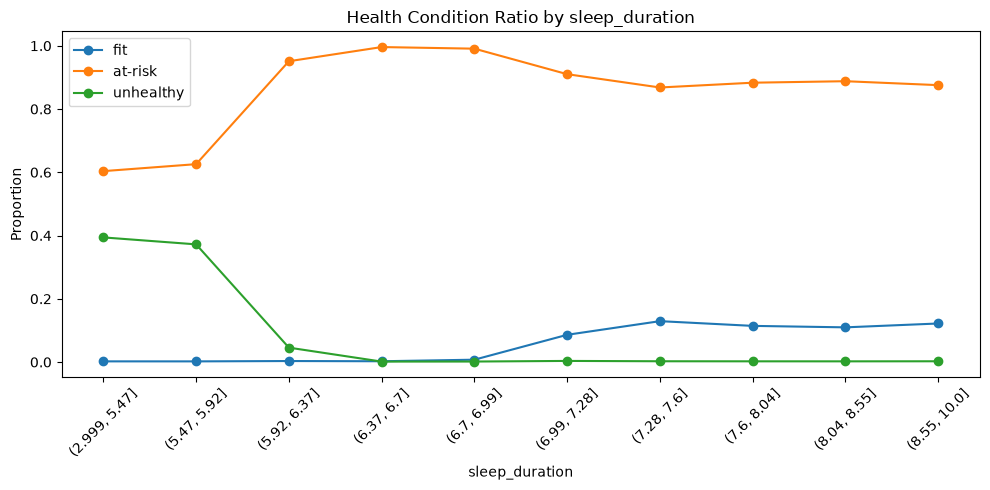

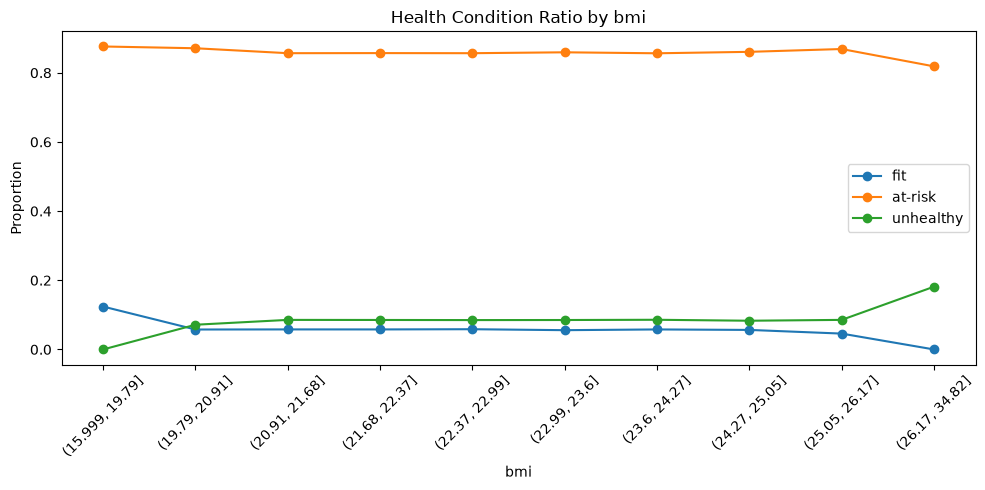

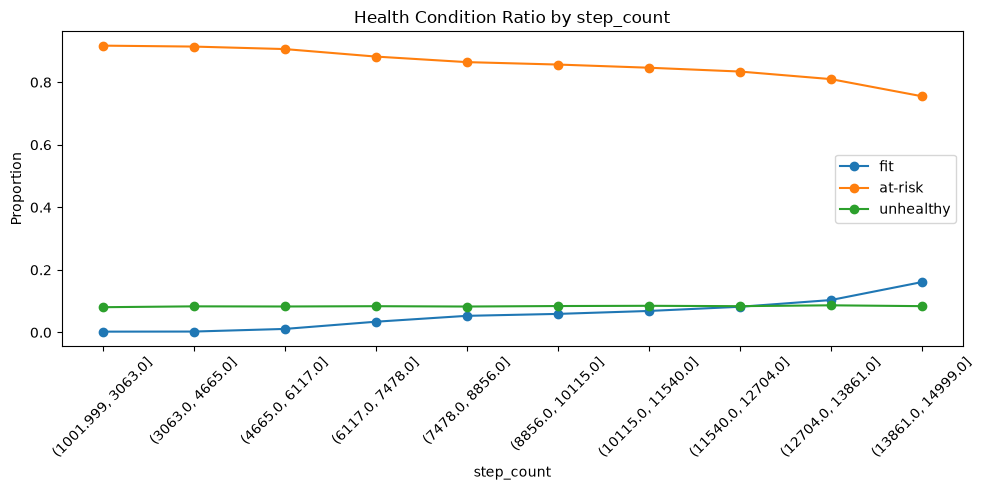

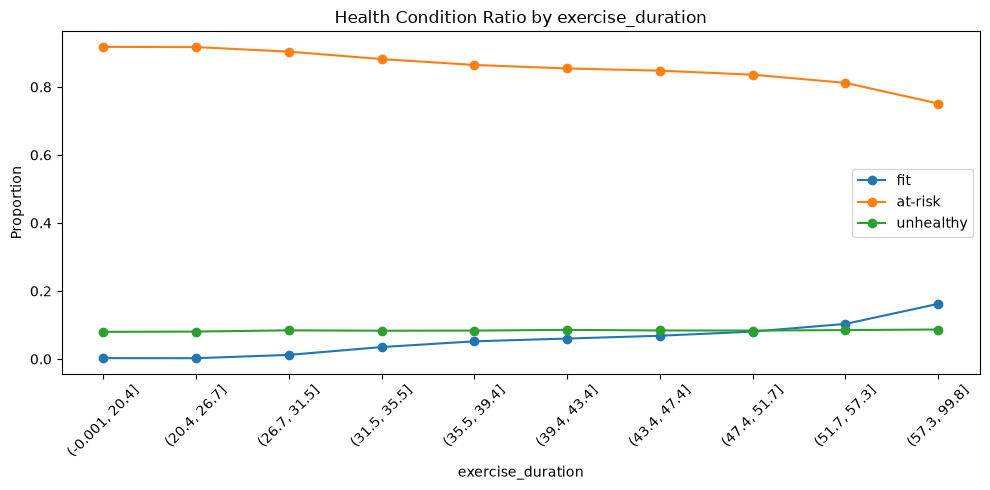

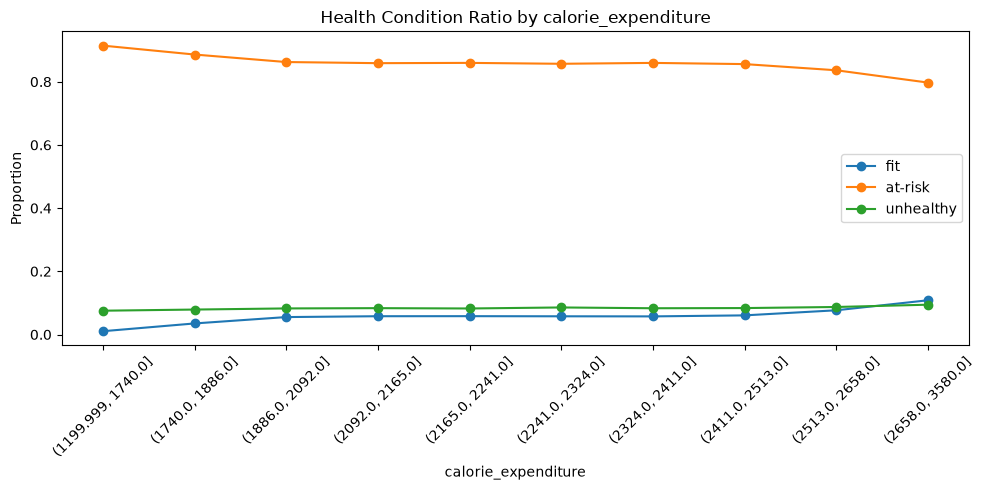

In [42]:
for col in strong_numeric_cols:
    temp = train[[col, "health_condition"]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[col],
        q=10,
        duplicates="drop"
    )

    ratio = pd.crosstab(
        temp["bin"],
        temp["health_condition"],
        normalize="index"
    )

    ratio.index = ratio.index.astype(str)

    plt.figure(figsize=(10, 5))

    for condition in ["fit", "at-risk", "unhealthy"]:
        plt.plot(
            ratio.index,
            ratio[condition],
            marker="o",
            label=condition
        )

    plt.title(f"Health Condition Ratio by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [43]:
corr = train[numeric_cols].corr()
corr.round(2)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
sleep_duration,1.00,-0.01,-0.07,-0.00,0.00,0.00,0.0
heart_rate,-0.01,1.00,0.00,-0.00,-0.01,-0.01,0.0
bmi,-0.07,0.00,1.00,0.12,-0.02,-0.02,0.0
calorie_expenditure,-0.00,-0.00,0.12,1.00,0.40,0.39,0.0
step_count,0.00,-0.01,-0.02,0.40,1.00,0.44,-0.0
exercise_duration,0.00,-0.01,-0.02,0.39,0.44,1.00,0.0
water_intake,0.00,0.00,0.00,0.00,-0.00,0.00,1.0


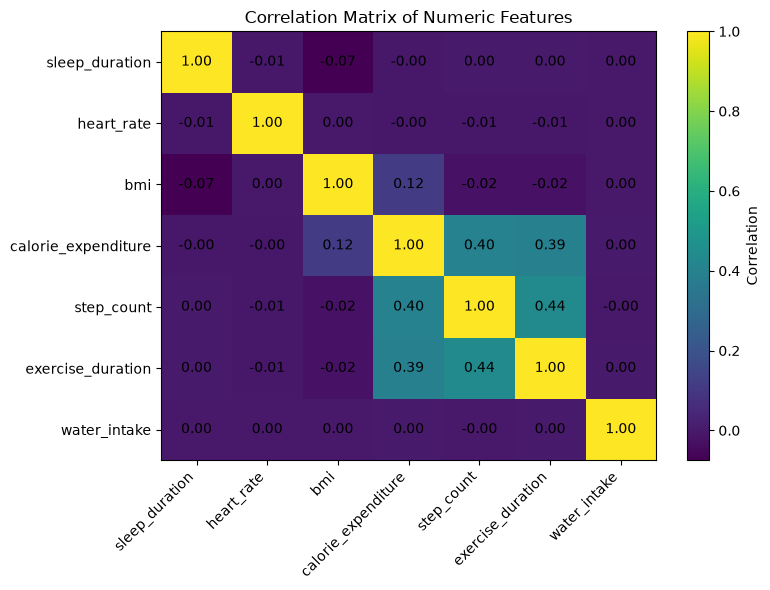

In [44]:
# 숫자형 변수끼리 관계 확인 - 중복 정보 있는지 확인
plt.figure(figsize=(8, 6))

plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numeric_cols)),
    numeric_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_cols)),
    numeric_cols
)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

숫자형 변수끼리 심한 중복은 없음

In [84]:
# BMI 결측 여부에 따른 health_condition 분포

bmi_missing = train["bmi"].isna()

bmi_missing_target = pd.crosstab(
    bmi_missing,
    train["health_condition"],
    normalize="index"
)

bmi_missing_target.index = ["BMI observed", "BMI missing"]

display(bmi_missing_target.round(4))

health_condition,at-risk,fit,unhealthy
BMI observed,0.8581,0.0572,0.0848
BMI missing,0.8888,0.0820,0.0293


In [85]:
train.loc[
    train["bmi"].isna(),
    "sleep_quality"
].value_counts(dropna=False)

sleep_quality
good    12677
NaN      1221
Name: count, dtype: int64

In [86]:
bmi_missing_by_sleep = (
    train
    .assign(bmi_missing=train["bmi"].isna())
    .groupby("sleep_quality", observed=True)["bmi_missing"]
    .agg(["count", "sum", "mean"])
)

bmi_missing_by_sleep.columns = [
    "total_count",
    "bmi_missing_count",
    "bmi_missing_ratio"
]

display(bmi_missing_by_sleep)

,total_count,bmi_missing_count,bmi_missing_ratio
sleep_quality,,,
average,213948,0,0.000000
good,205643,12677,0.061646
poor,212166,0,0.000000


In [87]:
good_sleep = train[
    train["sleep_quality"] == "good"
].copy()

pd.crosstab(
    good_sleep["bmi"].isna(),
    good_sleep["health_condition"],
    normalize="index"
).round(4)

health_condition,at-risk,fit,unhealthy
bmi,,,
False,0.8878,0.0817,0.0306
True,0.8881,0.0830,0.0290


BMI 결측 여부가 sleep_quality와 매우 강하게 연결되어 있으며, 따라서 BMI 결측은 완전히 무작위로 발생한 것으로 보기 어렵다.

CatBoost/LightGBM는 모델이 이 관계를 이미 자체적으로 활용.

In [88]:
# 숫자형 변수의 고유값 개수 및 반복 정도 확인

for col in numeric_cols:
    total = train[col].notna().sum()
    unique = train[col].nunique()

    print(
        f"{col:22s}",
        f"unique = {unique:6d}",
        f"total = {total:6d}",
        f"unique ratio = {unique / total:.4f}"
    )

sleep_duration         unique =    701 total = 614089 unique ratio = 0.0011
heart_rate             unique =    537 total = 682255 unique ratio = 0.0008
bmi                    unique =   1596 total = 676190 unique ratio = 0.0024
calorie_expenditure    unique =   2101 total = 637235 unique ratio = 0.0033
step_count             unique =  12807 total = 676172 unique ratio = 0.0189
exercise_duration      unique =    856 total = 683187 unique ratio = 0.0013
water_intake           unique =    400 total = 646611 unique ratio = 0.0006


In [89]:
# 숫자형 변수에서 자주 반복되는 값 확인

for col in numeric_cols:
    print(f"\n[{col}]")
    print(train[col].value_counts().head(10))


[sleep_duration]
sleep_duration
7.16    3436
7.17    3384
7.13    3137
6.81    3109
6.37    3080
7.43    3007
6.95    2965
6.97    2944
7.02    2932
7.03    2926
Name: count, dtype: int64

[heart_rate]
heart_rate
74.0    3941
76.7    3724
75.9    3697
74.3    3691
73.7    3641
74.4    3620
71.4    3620
76.3    3553
72.6    3535
76.5    3528
Name: count, dtype: int64

[bmi]
bmi
23.44    2261
21.76    2143
22.02    2004
21.47    1968
23.71    1955
23.03    1911
24.27    1891
24.33    1881
21.74    1848
22.77    1844
Name: count, dtype: int64

[calorie_expenditure]
calorie_expenditure
2201.0    2627
2103.0    2108
2248.0    1930
2333.0    1881
2182.0    1865
2247.0    1842
2199.0    1837
2274.0    1834
2155.0    1826
2175.0    1787
Name: count, dtype: int64

[step_count]
step_count
12182.0    817
12077.0    792
13897.0    712
12078.0    696
12779.0    694
9095.0     692
13495.0    666
14158.0    647
4892.0     615
13333.0    595
Name: count, dtype: int64

[exercise_duration]
exercise_dur

### 데이터 전처리

<baseline용 전처리>
* id -> 제거
* 숫자형 결측치: median으로 대체, 범주형 결측치: missing 이라는 새 범주로 대체
* 숫자형 변수: StandardScaler, 범주형 변수: One-Hot Encoding
* target 불균형: Logistic Regression에서 class_weight='balanced'
* validation 분할: stratify=y

In [45]:
# X,y 나누기
from sklearn.model_selection import train_test_split

X = train.drop(columns=["id", "health_condition"])
y = train["health_condition"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_valid.shape)
print(y_train.value_counts(normalize=True))
print(y_valid.value_counts(normalize=True))

(552070, 13) (138018, 13)
health_condition
at-risk      0.858676
unhealthy    0.083647
fit          0.057677
Name: proportion, dtype: float64
health_condition
at-risk      0.858671
unhealthy    0.083649
fit          0.057681
Name: proportion, dtype: float64


In [46]:
# 숫자형, 범주형 변수 지정
numeric_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

categorical_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

In [47]:
#전처리 파이프라인
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#숫자형
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
#범주형
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

### 두 번째 모델
Random Forest

- 결측치 처리: 숫자형(median), 범주형(missing)
- 범주형 encoding: One-Hot Encoding
- Class imbalance: class_weight='balanced'

**결과**
- Accuracy: 0.9486
- Balanced Accuracy: 0.9444
- Recall
    - at-risk: 0.95
    - fit: 0.94
    - unhealthy: 0.94

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=18, #일단 연산량 너무 안많게 조정..
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

In [49]:
rf_model.fit(X_train, y_train);

In [50]:
rf_pred = rf_model.predict(X_valid)

In [52]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report
)

In [53]:
print("Accuracy:", accuracy_score(y_valid, rf_pred))
print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_valid, rf_pred)
)

Accuracy: 0.9486371342868322
Balanced Accuracy: 0.9444120609907828


In [54]:
print(classification_report(y_valid, rf_pred))

              precision    recall  f1-score   support

     at-risk       0.99      0.95      0.97    118512
         fit       0.75      0.94      0.84      7961
   unhealthy       0.75      0.94      0.84     11545

    accuracy                           0.95    138018
   macro avg       0.83      0.94      0.88    138018
weighted avg       0.96      0.95      0.95    138018



### 결측치 처리 방법 바꿔보기
모델은 Random Forest  

현재 처리 방법: median & missing -> 0.9444  
시도해볼 것:  
- mean: 0.9447
- median + missing indicator: 0.9468
- iterative / 모델 기반 imputation: 0.9455
- KNNImputer (필요하면): 노트북 터질까봐 일단 생략

**결과**
Median과 Mean의 성능 차이는 매우 작았으나,  
수치형 결측치 여부를 추가 변수로 포함한 경우 Balanced Accuracy가 개선되었다.  
따라서 이후 모델에서는 Median Imputation + Missing Indicator 방식을 사용한다.  

In [55]:
# median + missing indicator
numeric_transformer_indicator = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", StandardScaler())
])

preprocessor_indicator = ColumnTransformer([
    ("num", numeric_transformer_indicator, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

rf_indicator = Pipeline([
    ("preprocessor", preprocessor_indicator),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_indicator.fit(X_train, y_train);

pred_indicator = rf_indicator.predict(X_valid)

print(
    "Median + Indicator Balanced Accuracy:",
    balanced_accuracy_score(y_valid, pred_indicator)
)

Median + Indicator Balanced Accuracy: 0.9468219554593872


### 피처 엔지니어링
- Sleep x BMI 인터랙션 피처 추가: 0.9479
- missing count 추가: 0.9480


In [56]:
#다변량 EDA
# 범주형 × 숫자형
def cat_num_interaction(df, cat_col, num_col, q=5):
    temp = df[[cat_col, num_col, "health_condition"]].dropna().copy()

    temp["num_bin"] = pd.qcut(
        temp[num_col],
        q=q,
        duplicates="drop"
    )

    ratio = pd.crosstab(
        [temp[cat_col], temp["num_bin"]],
        temp["health_condition"],
        normalize="index"
    )

    return ratio.round(3)

In [57]:
# 숫자형 × 숫자형
def num_num_interaction(df, col1, col2, q=5):
    temp = df[[col1, col2, "health_condition"]].dropna().copy()

    temp["bin1"] = pd.qcut(
        temp[col1],
        q=q,
        duplicates="drop"
    )

    temp["bin2"] = pd.qcut(
        temp[col2],
        q=q,
        duplicates="drop"
    )

    ratio = pd.crosstab(
        [temp["bin1"], temp["bin2"]],
        temp["health_condition"],
        normalize="index"
    )

    return ratio.round(3)

In [58]:
#sleep_duration × bmi
display(
    num_num_interaction(
        train,
        "sleep_duration",
        "bmi"
    )
)

health_condition               at-risk    fit  unhealthy
bin1          bin2                                      
(2.999, 5.91] (15.999, 20.91]    0.790  0.004      0.206
              (20.91, 22.37]     0.611  0.003      0.386
              (22.37, 23.6]      0.613  0.002      0.385
              (23.6, 25.05]      0.618  0.002      0.380
              (25.05, 34.82]     0.498  0.001      0.501
(5.91, 6.68]  (15.999, 20.91]    0.983  0.005      0.012
              (20.91, 22.37]     0.968  0.003      0.029
              (22.37, 23.6]      0.967  0.003      0.030
              (23.6, 25.05]      0.967  0.003      0.030
              (25.05, 34.82]     0.957  0.001      0.042
(6.68, 7.27]  (15.999, 20.91]    0.933  0.066      0.001
              (20.91, 22.37]     0.950  0.048      0.002
              (22.37, 23.6]      0.953  0.044      0.003
              (23.6, 25.05]      0.951  0.046      0.003
              (25.05, 34.82]     0.977  0.018      0.004
(7.27, 8.03]  (15.999, 20.91]    0.819  0.180      0.001
              (20.91, 22.37]     0.873  0.124      0.003
              (22.37, 23.6]      0.878  0.120      0.003
              (23.6, 25.05]      0.875  0.123      0.002
              (25.05, 34.82]     0.943  0.053      0.005
(8.03, 10.0]  (15.999, 20.91]    0.832  0.167      0.001
              (20.91, 22.37]     0.883  0.115      0.002
              (22.37, 23.6]      0.881  0.116      0.002
              (23.6, 25.05]      0.883  0.114      0.003
              (25.05, 34.82]     0.944  0.052      0.004

In [59]:
# Sleep x BMI 추가
# train 데이터에서만 구간 경계 계산
_, sleep_edges = pd.qcut(
    X_train["sleep_duration"].dropna(),
    q=5,
    retbins=True,
    duplicates="drop"
)

_, bmi_edges = pd.qcut(
    X_train["bmi"].dropna(),
    q=5,
    retbins=True,
    duplicates="drop"
)

# validation의 값이 train 범위를 약간 벗어나도 포함되도록
sleep_edges[0] = -np.inf
sleep_edges[-1] = np.inf

bmi_edges[0] = -np.inf
bmi_edges[-1] = np.inf

In [60]:
def add_sleep_bmi_feature(df):
    df = df.copy()

    sleep_bin = pd.cut(
        df["sleep_duration"],
        bins=sleep_edges,
        include_lowest=True
    )

    bmi_bin = pd.cut(
        df["bmi"],
        bins=bmi_edges,
        include_lowest=True
    )

    df["sleep_bmi"] = (
        sleep_bin.astype("object").fillna("missing").astype(str)
        + "_"
        + bmi_bin.astype("object").fillna("missing").astype(str)
    )

    return df

In [61]:
X_train_fe2 = add_sleep_bmi_feature(X_train)
X_valid_fe2 = add_sleep_bmi_feature(X_valid)

categorical_cols_fe2 = categorical_cols + ["sleep_bmi"]

In [62]:
preprocessor_fe2 = ColumnTransformer([
    ("num", numeric_transformer_indicator, numeric_cols),
    ("cat", categorical_transformer, categorical_cols_fe2)
])

In [63]:
rf_fe2 = Pipeline([
    ("preprocessor", preprocessor_fe2),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_fe2.fit(X_train_fe2, y_train);

In [64]:
pred_fe2 = rf_fe2.predict(X_valid_fe2)

print(
    "Sleep × BMI Balanced Accuracy:",
    balanced_accuracy_score(y_valid, pred_fe2)
)

Sleep × BMI Balanced Accuracy: 0.9479042740806664


In [65]:
# missing_count 추가
def add_missing_count_feature(df):
    result = add_sleep_bmi_feature(df)   # 현재 best의 sleep_bmi 유지
    result["missing_count"] = df.isna().sum(axis=1)
    return result

In [66]:
X_train_mc = add_missing_count_feature(X_train)
X_valid_mc = add_missing_count_feature(X_valid)

numeric_cols_mc = numeric_cols + ["missing_count"]
categorical_cols_mc = categorical_cols + ["sleep_bmi"]

In [67]:
preprocessor_mc = ColumnTransformer([
    ("num", numeric_transformer_indicator, numeric_cols_mc),
    ("cat", categorical_transformer, categorical_cols_mc)
])

rf_mc = Pipeline([
    ("preprocessor", preprocessor_mc),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_mc.fit(X_train_mc, y_train);

pred_mc = rf_mc.predict(X_valid_mc)

print(
    "Missing Count Balanced Accuracy:",
    balanced_accuracy_score(y_valid, pred_mc)
)

Missing Count Balanced Accuracy: 0.9480964542982786


In [68]:
# sleep_deviation 추가
def add_sleep_deviation_feature(df):
    result = add_sleep_bmi_feature(df)
    
    result["sleep_deviation"] = abs(
        result["sleep_duration"] - 8.0
    )
    
    return result

In [69]:
X_train_sd = add_sleep_deviation_feature(X_train)
X_valid_sd = add_sleep_deviation_feature(X_valid)

numeric_cols_sd = numeric_cols + ["sleep_deviation"]
categorical_cols_sd = categorical_cols + ["sleep_bmi"]

In [70]:
preprocessor_sd = ColumnTransformer([
    ("num", numeric_transformer_indicator, numeric_cols_sd),
    ("cat", categorical_transformer, categorical_cols_sd)
])

rf_sd = Pipeline([
    ("preprocessor", preprocessor_sd),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

rf_sd.fit(X_train_sd, y_train);

pred_sd = rf_sd.predict(X_valid_sd)

print(
    "Sleep Deviation Balanced Accuracy:",
    balanced_accuracy_score(y_valid, pred_sd)
)

Sleep Deviation Balanced Accuracy: 0.9476943243799724


In [90]:
# OOF Exact-Value TE 만들기
from sklearn.model_selection import StratifiedKFold

te_cols = numeric_cols

te_classes = [
    "at-risk",
    "fit",
    "unhealthy"
]

def make_exact_value_te(
    X_train,
    y_train,
    X_valid,
    cols,
    n_splits=5
):
    oof_te = pd.DataFrame(index=X_train.index)
    valid_te = pd.DataFrame(index=X_valid.index)

    # NaN도 하나의 값처럼 취급
    def keyify(series):
        return (
            series.astype("object")
            .where(series.notna(), "__MISSING__")
        )

    # 만들어질 열 미리 생성
    for col in cols:
        for cls in te_classes:
            oof_te[f"{col}_te_{cls}"] = np.nan

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # -------------------------
    # OOF Train TE
    # -------------------------
    for fold, (fit_idx, hold_idx) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):
        y_fit = y_train.iloc[fit_idx]

        fold_prior = (
            y_fit.value_counts(normalize=True)
            .reindex(te_classes)
            .fillna(0)
        )

        for col in cols:
            fit_keys = keyify(
                X_train.iloc[fit_idx][col]
            )

            hold_keys = keyify(
                X_train.iloc[hold_idx][col]
            )

            mapping = pd.crosstab(
                fit_keys,
                y_fit,
                normalize="index"
            ).reindex(
                columns=te_classes,
                fill_value=0
            )

            for cls in te_classes:
                new_col = f"{col}_te_{cls}"

                encoded = (
                    hold_keys
                    .map(mapping[cls])
                    .fillna(fold_prior[cls])
                )

                oof_te.iloc[
                    hold_idx,
                    oof_te.columns.get_loc(new_col)
                ] = encoded.to_numpy()

        print(f"Fold {fold} completed")

    # -------------------------
    # Validation TE
    # X_train 전체로 mapping 생성
    # -------------------------
    full_prior = (
        y_train.value_counts(normalize=True)
        .reindex(te_classes)
        .fillna(0)
    )

    for col in cols:
        train_keys = keyify(X_train[col])
        valid_keys = keyify(X_valid[col])

        mapping = pd.crosstab(
            train_keys,
            y_train,
            normalize="index"
        ).reindex(
            columns=te_classes,
            fill_value=0
        )

        for cls in te_classes:
            valid_te[f"{col}_te_{cls}"] = (
                valid_keys
                .map(mapping[cls])
                .fillna(full_prior[cls])
            )

    return oof_te, valid_te

In [91]:
X_train_te, X_valid_te = make_exact_value_te(
    X_train,
    y_train,
    X_valid,
    cols=numeric_cols,
    n_splits=5
)

print("Train TE shape:", X_train_te.shape)
print("Valid TE shape:", X_valid_te.shape)

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Train TE shape: (552070, 21)
Valid TE shape: (138018, 21)


In [92]:
X_train_te.head()

,sleep_duration_te_at-risk,sleep_duration_te_fit,sleep_duration_te_unhealthy,heart_rate_te_at-risk,heart_rate_te_fit,heart_rate_te_unhealthy,bmi_te_at-risk,bmi_te_fit,bmi_te_unhealthy,calorie_expenditure_te_at-risk,...,calorie_expenditure_te_unhealthy,step_count_te_at-risk,step_count_te_fit,step_count_te_unhealthy,exercise_duration_te_at-risk,exercise_duration_te_fit,exercise_duration_te_unhealthy,water_intake_te_at-risk,water_intake_te_fit,water_intake_te_unhealthy
313415,0.902076,0.094765,0.003159,0.868132,0.060440,0.071429,0.879828,0.000000,0.120172,0.771863,...,0.114068,0.803571,0.000000,0.196429,0.848402,0.076712,0.074886,0.897094,0.038291,0.064615
3515,0.858580,0.057640,0.083780,0.848126,0.052268,0.099606,0.876056,0.039437,0.084507,0.869091,...,0.084848,0.800000,0.133333,0.066667,0.837838,0.083784,0.078378,0.859583,0.056926,0.083491
501194,0.921525,0.078475,0.000000,0.881684,0.038770,0.079545,0.820796,0.077434,0.101770,0.850700,...,0.082426,0.875000,0.078125,0.046875,0.927126,0.001350,0.071525,0.806383,0.077660,0.115957
303602,0.858627,0.058043,0.083330,0.850714,0.063666,0.085620,0.856164,0.071918,0.071918,0.882521,...,0.063037,0.904762,0.047619,0.047619,0.914081,0.001193,0.084726,0.817920,0.078915,0.103165
117943,0.897351,0.102649,0.000000,0.891479,0.036174,0.072347,0.908297,0.039301,0.052402,0.838509,...,0.105590,0.615385,0.269231,0.115385,0.827189,0.100230,0.072581,0.881301,0.057561,0.061138


### Exact-Value Target Encoding - All Features

In [117]:
all_te_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

In [118]:
X_train_te_all, X_valid_te_all = make_exact_value_te(
    X_train,
    y_train,
    X_valid,
    cols=all_te_cols,
    n_splits=5
)

print("Train TE shape:", X_train_te_all.shape)
print("Valid TE shape:", X_valid_te_all.shape)

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Train TE shape: (552070, 39)
Valid TE shape: (138018, 39)


### 다른 모델2
CatBoost
- 0.9497  => **채택**
    - 파라미터 조정 해봤는데 성능 개선 없어서 걍 초반 설정 유지 
    - Sleep x BMI interaction이랑 missing count 모두 사용할 때가 가장 성능 높게 나옴 


In [71]:
def prepare_catboost_data(df):
    result = add_sleep_bmi_feature(df)

    # 원본 feature들의 결측 개수
    result["missing_count"] = df.isna().sum(axis=1)

    # CatBoost categorical feature의 NaN은 문자열로 처리
    cat_cols = [
        "diet_type",
        "stress_level",
        "sleep_quality",
        "physical_activity_level",
        "smoking_alcohol",
        "gender",
        "sleep_bmi"
    ]

    for col in cat_cols:
        result[col] = result[col].fillna("missing").astype(str)

    return result

In [72]:
X_train_cb = prepare_catboost_data(X_train)
X_valid_cb = prepare_catboost_data(X_valid)

cat_cols_cb = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender",
    "sleep_bmi"
]

In [73]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

In [74]:
cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_cols_cb,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=50
);

0:	learn: 0.9387574	test: 0.9385815	best: 0.9385815 (0)	total: 1.05s	remaining: 8m 42s
100:	learn: 0.1722899	test: 0.1778018	best: 0.1778018 (100)	total: 1m 41s	remaining: 6m 42s
200:	learn: 0.1617100	test: 0.1751915	best: 0.1751793 (198)	total: 3m 27s	remaining: 5m 9s
300:	learn: 0.1531411	test: 0.1747294	best: 0.1747176 (297)	total: 5m 11s	remaining: 3m 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1745857058
bestIteration = 328

Shrink model to first 329 iterations.


In [75]:
cat_pred = cat_model.predict(X_valid_cb).ravel()

In [76]:
print(
    "CatBoost Balanced Accuracy:",
    balanced_accuracy_score(y_valid, cat_pred)
)

print(
    "Accuracy:",
    accuracy_score(y_valid, cat_pred)
)

CatBoost Balanced Accuracy: 0.9497775382677062
Accuracy: 0.9377907229491805


In [77]:
print(classification_report(y_valid, cat_pred))

              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    118512
         fit       0.73      0.95      0.83      7961
   unhealthy       0.69      0.97      0.80     11545

    accuracy                           0.94    138018
   macro avg       0.80      0.95      0.86    138018
weighted avg       0.95      0.94      0.94    138018



In [78]:
print("Best iteration:", cat_model.get_best_iteration())
print("Best score:", cat_model.get_best_score())

Best iteration: 328
Best score: {'learn': {'MultiClass': 0.1475486339310342}, 'validation': {'MultiClass': 0.17458570577703156}}


In [93]:
X_train_cb_te = prepare_catboost_data(X_train).join(
    X_train_te
)

X_valid_cb_te = prepare_catboost_data(X_valid).join(
    X_valid_te
)

print(X_train_cb_te.shape)
print(X_valid_cb_te.shape)

(552070, 36)
(138018, 36)


In [94]:
cat_model_te = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

cat_model_te.fit(
    X_train_cb_te,
    y_train,
    cat_features=cat_cols_cb,
    eval_set=(X_valid_cb_te, y_valid),
    early_stopping_rounds=50
);

0:	learn: 0.9387269	test: 0.9380028	best: 0.9380028 (0)	total: 1.18s	remaining: 9m 46s
100:	learn: 0.1635445	test: 0.1731375	best: 0.1731375 (100)	total: 1m 44s	remaining: 6m 54s
200:	learn: 0.1513858	test: 0.1709868	best: 0.1709381 (192)	total: 3m 40s	remaining: 5m 27s
300:	learn: 0.1420080	test: 0.1705125	best: 0.1705071 (294)	total: 5m 34s	remaining: 3m 41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1704764487
bestIteration = 323

Shrink model to first 324 iterations.


In [95]:
cat_te_pred = cat_model_te.predict(
    X_valid_cb_te
).ravel()

cat_te_score = balanced_accuracy_score(
    y_valid,
    cat_te_pred
)

print(
    "CatBoost + Exact-Value TE Balanced Accuracy:",
    cat_te_score
)

print(
    "Best iteration:",
    cat_model_te.get_best_iteration()
)

CatBoost + Exact-Value TE Balanced Accuracy: 0.9496942140370087
Best iteration: 323


### 13개 TE

In [119]:
X_train_cb_te_all = X_train_cb.join(X_train_te_all)
X_valid_cb_te_all = X_valid_cb.join(X_valid_te_all)

print("Train shape:", X_train_cb_te_all.shape)
print("Valid shape:", X_valid_cb_te_all.shape)

Train shape: (552070, 54)
Valid shape: (138018, 54)


In [120]:
cat_model_te_all = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

cat_model_te_all.fit(
    X_train_cb_te_all,
    y_train,
    cat_features=cat_cols_cb,
    eval_set=(X_valid_cb_te_all, y_valid),
    early_stopping_rounds=50
);

0:	learn: 0.9382622	test: 0.9380314	best: 0.9380314 (0)	total: 1.8s	remaining: 14m 56s
100:	learn: 0.1620593	test: 0.1733477	best: 0.1733477 (100)	total: 1m 50s	remaining: 7m 16s
200:	learn: 0.1498178	test: 0.1712901	best: 0.1712901 (200)	total: 3m 45s	remaining: 5m 35s
300:	learn: 0.1400848	test: 0.1709575	best: 0.1709360 (295)	total: 5m 47s	remaining: 3m 49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1707683885
bestIteration = 345

Shrink model to first 346 iterations.


In [121]:
cat_te_all_pred = cat_model_te_all.predict(
    X_valid_cb_te_all
).ravel()

cat_te_all_score = balanced_accuracy_score(
    y_valid,
    cat_te_all_pred
)

print(
    "CatBoost + All-Feature Exact-Value TE Balanced Accuracy:",
    cat_te_all_score
)

print(
    "Best iteration:",
    cat_model_te_all.get_best_iteration()
)

CatBoost + All-Feature Exact-Value TE Balanced Accuracy: 0.9500474004557957
Best iteration: 345


### Exact-Value Target Encoding 실험

숫자형 변수에서 동일 값이 반복되는 구조를 확인하여 OOF 기반 Exact-Value Target Encoding을 추가해 보았으나,

- 기존 CatBoost: 0.94978
- + Exact-Value TE: 0.94969

로 성능이 소폭 감소하여 최종 feature에는 포함하지 않음.

### Unweighted CatBoost + Prior Correction

In [96]:
cat_unweighted = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

cat_unweighted.fit(
    X_train_cb,
    y_train,
    cat_features=cat_cols_cb,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=50
);

0:	learn: 0.9264592	test: 0.9257718	best: 0.9257718 (0)	total: 852ms	remaining: 7m 4s
100:	learn: 0.0914562	test: 0.0916515	best: 0.0916515 (100)	total: 1m 31s	remaining: 6m 1s
200:	learn: 0.0887932	test: 0.0905043	best: 0.0905036 (198)	total: 3m 11s	remaining: 4m 44s
300:	learn: 0.0867451	test: 0.0901426	best: 0.0901426 (300)	total: 4m 55s	remaining: 3m 15s
400:	learn: 0.0849741	test: 0.0899704	best: 0.0899692 (399)	total: 6m 54s	remaining: 1m 42s
499:	learn: 0.0832492	test: 0.0898611	best: 0.0898496 (492)	total: 8m 54s	remaining: 0us

bestTest = 0.08984960897
bestIteration = 492

Shrink model to first 493 iterations.


In [97]:
unweighted_pred = cat_unweighted.predict(X_valid_cb).ravel()

print(
    "Unweighted CatBoost Balanced Accuracy:",
    balanced_accuracy_score(y_valid, unweighted_pred)
)

print(
    "Best iteration:",
    cat_unweighted.get_best_iteration()
)

Unweighted CatBoost Balanced Accuracy: 0.8735990251222004
Best iteration: 492


In [98]:
unweighted_proba = cat_unweighted.predict_proba(X_valid_cb)

print(cat_unweighted.classes_)

['at-risk' 'fit' 'unhealthy']


In [99]:
class_order = cat_unweighted.classes_

class_prior = (
    y_train
    .value_counts(normalize=True)
    .reindex(class_order)
    .values
)

print(class_prior)

[0.85867553 0.05767747 0.083647  ]


In [100]:
corrected_scores = unweighted_proba / class_prior

In [101]:
corrected_pred = class_order[
    np.argmax(corrected_scores, axis=1)
]

In [102]:
prior_corrected_score = balanced_accuracy_score(
    y_valid,
    corrected_pred
)

print(
    "Unweighted CatBoost + Prior Correction:",
    prior_corrected_score
)

Unweighted CatBoost + Prior Correction: 0.9493078202268


### 다른 모델3
LightGBM
- 0.9489
    - CatBoost보다는 낮으나 많이 차이는 안남

In [79]:
X_train_lgb = X_train_cb.copy()
X_valid_lgb = X_valid_cb.copy()

In [80]:
cat_cols_lgb = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender",
    "sleep_bmi"
]

for col in cat_cols_lgb:
    categories = X_train_lgb[col].astype(str).unique()

    X_train_lgb[col] = pd.Categorical(
        X_train_lgb[col].astype(str),
        categories=categories
    )

    X_valid_lgb[col] = pd.Categorical(
        X_valid_lgb[col].astype(str),
        categories=categories
    )

In [81]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

lgb_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [82]:
lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    categorical_feature=cat_cols_lgb,
    callbacks=[
        early_stopping(50),
        log_evaluation(100)
    ]
);

c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1857
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.190777
[200]	valid_0's multi_logloss: 0.184296
[300]	valid_0's multi_logloss: 0.17963
[400]	valid_0's multi_logloss: 0.175362
[500]	valid_0's multi_logloss: 0.171549
[600]	valid_0's multi_logloss: 0.167887
[700]	valid_0's multi_logloss: 0.164355
[800]	valid_0's multi_logloss: 0.160925
[900]	valid_0's multi_logloss: 0.157789
[1000]	valid_0's multi_logloss: 0.155026
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.15502

In [83]:
lgb_pred = lgb_model.predict(X_valid_lgb)

print(
    "LightGBM Balanced Accuracy:",
    balanced_accuracy_score(y_valid, lgb_pred)
)

print(
    "Accuracy:",
    accuracy_score(y_valid, lgb_pred)
)

LightGBM Balanced Accuracy: 0.948912342817838
Accuracy: 0.9422394180469215


### 앙상블
1. Equal-weight Soft Voting  
CatBoost, LightGBM, Random Forest의 예측 확률을 동일한 비율로 평균하여 최종 클래스를 예측함. -> x 성능 떨어짐  

2. Weighted Soft Voting  


In [103]:
cat_proba = cat_model.predict_proba(X_valid_cb)
lgb_proba = lgb_model.predict_proba(X_valid_lgb)
rf_proba = rf_model.predict_proba(X_valid)

In [104]:
print("CatBoost:", cat_model.classes_)
print("LightGBM:", lgb_model.classes_)
print("Random Forest:", rf_model.classes_)

CatBoost: ['at-risk' 'fit' 'unhealthy']
LightGBM: ['at-risk' 'fit' 'unhealthy']
Random Forest: ['at-risk' 'fit' 'unhealthy']


In [105]:
ensemble_proba = (
    cat_proba
    + lgb_proba
    + rf_proba
) / 3

In [106]:
class_order = cat_model.classes_

ensemble_pred = class_order[
    np.argmax(ensemble_proba, axis=1)
]

In [107]:
ensemble_score = balanced_accuracy_score(
    y_valid,
    ensemble_pred
)

print(
    "Equal-weight Ensemble Balanced Accuracy:",
    ensemble_score
)

Equal-weight Ensemble Balanced Accuracy: 0.9492427696807177


In [108]:
# CatBoost에 더 높은 가중치를 둔 Soft Voting

weight_cases = {
    "Cat 0.6 + LGB 0.25 + RF 0.15": (0.60, 0.25, 0.15),
    "Cat 0.7 + LGB 0.2 + RF 0.1": (0.70, 0.20, 0.10),
    "Cat 0.8 + LGB 0.15 + RF 0.05": (0.80, 0.15, 0.05),
}

for name, (w_cat, w_lgb, w_rf) in weight_cases.items():
    
    weighted_proba = (
        w_cat * cat_proba
        + w_lgb * lgb_proba
        + w_rf * rf_proba
    )

    weighted_pred = class_order[
        np.argmax(weighted_proba, axis=1)
    ]

    score = balanced_accuracy_score(
        y_valid,
        weighted_pred
    )

    print(f"{name}: {score:.9f}")

Cat 0.6 + LGB 0.25 + RF 0.15: 0.949926855
Cat 0.7 + LGB 0.2 + RF 0.1: 0.949788057
Cat 0.8 + LGB 0.15 + RF 0.05: 0.950057481


In [109]:
# CatBoost + LightGBM만 사용한 앙상블

for cat_weight in [0.6, 0.7, 0.8, 0.9]:
    
    lgb_weight = 1 - cat_weight

    blend_proba = (
        cat_weight * cat_proba
        + lgb_weight * lgb_proba
    )

    blend_pred = class_order[
        np.argmax(blend_proba, axis=1)
    ]

    score = balanced_accuracy_score(
        y_valid,
        blend_pred
    )

    print(
        f"Cat {cat_weight:.1f} + "
        f"LGB {lgb_weight:.1f}: "
        f"{score:.9f}"
    )

Cat 0.6 + LGB 0.4: 0.950038897
Cat 0.7 + LGB 0.3: 0.950050427
Cat 0.8 + LGB 0.2: 0.950035641
Cat 0.9 + LGB 0.1: 0.949979240


### 3-fold OOF 기반 Ensemble 검증

In [110]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import numpy as np
import pandas as pd

In [111]:
# OOF에서 fold별로 sleep_bmi를 생성하는 함수

def make_fold_features(X_fit, X_hold):
    X_fit = X_fit.copy()
    X_hold = X_hold.copy()

    # fold 학습 데이터에서만 구간 경계 계산
    _, sleep_edges = pd.qcut(
        X_fit["sleep_duration"].dropna(),
        q=5,
        retbins=True,
        duplicates="drop"
    )

    _, bmi_edges = pd.qcut(
        X_fit["bmi"].dropna(),
        q=5,
        retbins=True,
        duplicates="drop"
    )

    sleep_edges[0], sleep_edges[-1] = -np.inf, np.inf
    bmi_edges[0], bmi_edges[-1] = -np.inf, np.inf

    def add_features(df):
        result = df.copy()

        sleep_bin = pd.cut(
            result["sleep_duration"],
            bins=sleep_edges,
            include_lowest=True
        )

        bmi_bin = pd.cut(
            result["bmi"],
            bins=bmi_edges,
            include_lowest=True
        )

        sleep_text = (
            sleep_bin.astype("object")
            .where(sleep_bin.notna(), "missing")
            .astype(str)
        )

        bmi_text = (
            bmi_bin.astype("object")
            .where(bmi_bin.notna(), "missing")
            .astype(str)
        )

        result["sleep_bmi"] = sleep_text + "_" + bmi_text

        # 원래 변수들의 결측 개수
        result["missing_count"] = df.isna().sum(axis=1)

        return result

    return add_features(X_fit), add_features(X_hold)

In [112]:
cat_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender",
    "sleep_bmi"
]

In [113]:
def prepare_cb_fold(X_fit, X_hold):
    X_fit = X_fit.copy()
    X_hold = X_hold.copy()

    for col in cat_cols:
        X_fit[col] = X_fit[col].fillna("missing").astype(str)
        X_hold[col] = X_hold[col].fillna("missing").astype(str)

    return X_fit, X_hold


def prepare_lgb_fold(X_fit, X_hold):
    X_fit = X_fit.copy()
    X_hold = X_hold.copy()

    for col in cat_cols:
        # training fold에서 category 목록 결정
        train_values = X_fit[col].fillna("missing").astype(str)

        categories = train_values.unique()

        X_fit[col] = pd.Categorical(
            train_values,
            categories=categories
        )

        X_hold[col] = pd.Categorical(
            X_hold[col].fillna("missing").astype(str),
            categories=categories
        )

    return X_fit, X_hold

In [114]:
X_oof = train.drop(
    columns=["id", "health_condition"]
).copy()

y_oof = train["health_condition"].copy()

class_order = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

n_classes = len(class_order)

oof_cat = np.zeros((len(train), n_classes))
oof_lgb = np.zeros((len(train), n_classes))

In [115]:
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for fold, (fit_idx, hold_idx) in enumerate(
    skf.split(X_oof, y_oof),
    start=1
):

    print(f"\n========== Fold {fold} ==========")

    X_fit_raw = X_oof.iloc[fit_idx]
    X_hold_raw = X_oof.iloc[hold_idx]

    y_fit = y_oof.iloc[fit_idx]
    y_hold = y_oof.iloc[hold_idx]

    # -------------------------
    # Feature Engineering
    # -------------------------
    X_fit_fe, X_hold_fe = make_fold_features(
        X_fit_raw,
        X_hold_raw
    )

    # =========================
    # CatBoost
    # =========================
    X_fit_cb, X_hold_cb = prepare_cb_fold(
        X_fit_fe,
        X_hold_fe
    )

    cat_fold = CatBoostClassifier(
        iterations=500,
        depth=8,
        learning_rate=0.1,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    cat_fold.fit(
        X_fit_cb,
        y_fit,
        cat_features=cat_cols,
        eval_set=(X_hold_cb, y_hold),
        early_stopping_rounds=50
    )

    cat_prob = cat_fold.predict_proba(X_hold_cb)

    # CatBoost 클래스 순서를 우리가 정한 순서로 맞춤
    cat_positions = [
        list(cat_fold.classes_).index(cls)
        for cls in class_order
    ]

    oof_cat[hold_idx] = cat_prob[:, cat_positions]

    # =========================
    # LightGBM
    # =========================
    X_fit_lgb, X_hold_lgb = prepare_lgb_fold(
        X_fit_fe,
        X_hold_fe
    )

    lgb_fold = LGBMClassifier(
        objective="multiclass",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    lgb_fold.fit(
        X_fit_lgb,
        y_fit,
        eval_set=[(X_hold_lgb, y_hold)],
        callbacks=[
            early_stopping(50, verbose=False),
            log_evaluation(0)
        ]
    )

    lgb_prob = lgb_fold.predict_proba(X_hold_lgb)

    lgb_positions = [
        list(lgb_fold.classes_).index(cls)
        for cls in class_order
    ]

    oof_lgb[hold_idx] = lgb_prob[:, lgb_positions]

    # fold별 참고 점수
    cat_pred_fold = class_order[
        np.argmax(oof_cat[hold_idx], axis=1)
    ]

    lgb_pred_fold = class_order[
        np.argmax(oof_lgb[hold_idx], axis=1)
    ]

    print(
        "CatBoost:",
        balanced_accuracy_score(
            y_hold,
            cat_pred_fold
        )
    )

    print(
        "LightGBM:",
        balanced_accuracy_score(
            y_hold,
            lgb_pred_fold
        )
    )


========== Fold 1 ==========


c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1858
[LightGBM] [Info] Number of data points in the train set: 460058, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
CatBoost: 0.9501437666014079
LightGBM: 0.9496024367804373

========== Fold 2 ==========


c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1858
[LightGBM] [Info] Number of data points in the train set: 460059, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
CatBoost: 0.9491792129163931
LightGBM: 0.948630944883598

========== Fold 3 ==========


c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1856
[LightGBM] [Info] Number of data points in the train set: 460059, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
CatBoost: 0.9475476151230465
LightGBM: 0.9467622958969099


In [116]:
# CatBoost OOF
oof_cat_pred = class_order[
    np.argmax(oof_cat, axis=1)
]

cat_oof_score = balanced_accuracy_score(
    y_oof,
    oof_cat_pred
)


# LightGBM OOF
oof_lgb_pred = class_order[
    np.argmax(oof_lgb, axis=1)
]

lgb_oof_score = balanced_accuracy_score(
    y_oof,
    oof_lgb_pred
)


# 기존 validation에서 선택한 0.7 : 0.3을 그대로 사용
oof_ensemble_proba = (
    0.7 * oof_cat
    + 0.3 * oof_lgb
)

oof_ensemble_pred = class_order[
    np.argmax(oof_ensemble_proba, axis=1)
]

ensemble_oof_score = balanced_accuracy_score(
    y_oof,
    oof_ensemble_pred
)


print("OOF CatBoost       :", cat_oof_score)
print("OOF LightGBM       :", lgb_oof_score)
print("OOF Cat 0.7 + LGB 0.3:", ensemble_oof_score)

OOF CatBoost       : 0.9489568592088787
OOF LightGBM       : 0.9483318947688328
OOF Cat 0.7 + LGB 0.3: 0.94947756456287


### 3-Fold OOF - CatBoost + All-Feature Exact-Value TE

In [122]:
# CatBoost + All-Feature Exact-Value TE의 3-Fold OOF 검증

skf_te = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

oof_cat_te_all = np.zeros(
    (len(train), len(class_order))
)

for fold, (fit_idx, hold_idx) in enumerate(
    skf_te.split(X_oof, y_oof),
    start=1
):
    print(f"\n========== Fold {fold} ==========")

    X_fit_raw = X_oof.iloc[fit_idx].copy()
    X_hold_raw = X_oof.iloc[hold_idx].copy()

    y_fit = y_oof.iloc[fit_idx]
    y_hold = y_oof.iloc[hold_idx]

    # 1) sleep_bmi + missing_count
    # outer training fold만 사용해서 sleep_bmi 구간 생성
    X_fit_fe, X_hold_fe = make_fold_features(
        X_fit_raw,
        X_hold_raw
    )

    # 2) 13개 전체 변수 Exact-Value TE
    # X_fit은 내부 OOF 방식으로 TE 생성
    # X_hold는 X_fit 전체에서 만든 mapping만 사용
    X_fit_te, X_hold_te = make_exact_value_te(
        X_fit_raw,
        y_fit,
        X_hold_raw,
        cols=all_te_cols,
        n_splits=5
    )

    # 3) 기존 feature + TE 결합
    X_fit_full = X_fit_fe.join(X_fit_te)
    X_hold_full = X_hold_fe.join(X_hold_te)

    # 4) CatBoost용 범주형 처리
    X_fit_cb, X_hold_cb = prepare_cb_fold(
        X_fit_full,
        X_hold_full
    )

    # 5) CatBoost 학습
    cat_te_fold = CatBoostClassifier(
        iterations=500,
        depth=8,
        learning_rate=0.1,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    cat_te_fold.fit(
        X_fit_cb,
        y_fit,
        cat_features=cat_cols,
        eval_set=(X_hold_cb, y_hold),
        early_stopping_rounds=50
    )

    # 6) 확률 예측
    fold_proba = cat_te_fold.predict_proba(
        X_hold_cb
    )

    # 클래스 순서 통일
    positions = [
        list(cat_te_fold.classes_).index(cls)
        for cls in class_order
    ]

    oof_cat_te_all[hold_idx] = (
        fold_proba[:, positions]
    )

    # Fold별 점수
    fold_pred = class_order[
        np.argmax(
            oof_cat_te_all[hold_idx],
            axis=1
        )
    ]

    fold_score = balanced_accuracy_score(
        y_hold,
        fold_pred
    )

    print(
        f"Fold {fold} Balanced Accuracy:",
        fold_score
    )


========== Fold 1 ==========
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Fold 1 Balanced Accuracy: 0.9506522498819017

========== Fold 2 ==========
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Fold 2 Balanced Accuracy: 0.9501915759076288

========== Fold 3 ==========
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Fold 3 Balanced Accuracy: 0.9484628222775395


In [123]:
cat_te_all_oof_pred = class_order[
    np.argmax(
        oof_cat_te_all,
        axis=1
    )
]

cat_te_all_oof_score = balanced_accuracy_score(
    y_oof,
    cat_te_all_oof_pred
)

print(
    "OOF CatBoost + All-Feature TE:",
    cat_te_all_oof_score
)

print(
    "OOF Original CatBoost:",
    0.9489568592088787
)

print(
    "OOF Cat 0.7 + LGB 0.3:",
    0.94947756456287
)

OOF CatBoost + All-Feature TE: 0.9497688732731203
OOF Original CatBoost: 0.9489568592088787
OOF Cat 0.7 + LGB 0.3: 0.94947756456287


### OOF Ensemble - TE CatBoost + LightGBM

In [124]:
# TE CatBoost + LightGBM OOF Ensemble

te_ensemble_cases = {
    "TE Cat 0.6 + LGB 0.4": (0.6, 0.4),
    "TE Cat 0.7 + LGB 0.3": (0.7, 0.3),
    "TE Cat 0.8 + LGB 0.2": (0.8, 0.2),
    "TE Cat 0.9 + LGB 0.1": (0.9, 0.1),
}

for name, (w_cat, w_lgb) in te_ensemble_cases.items():

    blend_proba = (
        w_cat * oof_cat_te_all
        + w_lgb * oof_lgb
    )

    blend_pred = class_order[
        np.argmax(blend_proba, axis=1)
    ]

    score = balanced_accuracy_score(
        y_oof,
        blend_pred
    )

    print(f"{name}: {score:.9f}")

TE Cat 0.6 + LGB 0.4: 0.950162346
TE Cat 0.7 + LGB 0.3: 0.950086881
TE Cat 0.8 + LGB 0.2: 0.949990803
TE Cat 0.9 + LGB 0.1: 0.949919660


### OOF Error Correlation

In [125]:
# TE CatBoost와 LightGBM의 OOF 오류 상관관계 확인

cat_pred = class_order[
    np.argmax(oof_cat_te_all, axis=1)
]

lgb_pred = class_order[
    np.argmax(oof_lgb, axis=1)
]

cat_error = (cat_pred != y_oof.to_numpy()).astype(int)
lgb_error = (lgb_pred != y_oof.to_numpy()).astype(int)

error_corr = np.corrcoef(
    cat_error,
    lgb_error
)[0, 1]

same_prediction = np.mean(
    cat_pred == lgb_pred
)

both_wrong = np.mean(
    (cat_error == 1) &
    (lgb_error == 1)
)

print("Error correlation:", error_corr)
print("Same prediction ratio:", same_prediction)
print("Both wrong ratio:", both_wrong)

Error correlation: 0.9108484610495532
Same prediction ratio: 0.9898085461564322
Both wrong ratio: 0.05352360858325315


### LightGBM + All-Feature Exact-Value TE

In [126]:
# 기존 LightGBM 입력 데이터에 39개 Exact-Value TE 추가

X_train_lgb_te = X_train_lgb.join(X_train_te_all)
X_valid_lgb_te = X_valid_lgb.join(X_valid_te_all)

print("Train shape:", X_train_lgb_te.shape)
print("Valid shape:", X_valid_lgb_te.shape)

Train shape: (552070, 54)
Valid shape: (138018, 54)


In [128]:
lgb_model_te = LGBMClassifier(
    objective="multiclass",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgb_model_te.fit(
    X_train_lgb_te,
    y_train,
    eval_set=[(X_valid_lgb_te, y_valid)],
    callbacks=[
        early_stopping(50),
        log_evaluation(100)
    ]
);

c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.050198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7588
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 54
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.185042
[200]	valid_0's multi_logloss: 0.176601
[300]	valid_0's multi_logloss: 0.17087
[400]	valid_0's multi_logloss: 0.165544
[500]	valid_0's multi_logloss: 0.160907
[600]	valid_0's multi_logloss: 0.156789
[700]	valid_0's multi_logloss: 0.152983
[800]	valid_0's multi_logloss: 0.14956
[900]	valid_0's multi_logloss: 0.146482
[1000]	valid_0's multi_logloss: 0.143841
Did not meet early stopping. Best iteration is:
[1000]	valid_0's multi_logloss: 0.143841

In [129]:
lgb_te_pred = lgb_model_te.predict(
    X_valid_lgb_te
)

lgb_te_score = balanced_accuracy_score(
    y_valid,
    lgb_te_pred
)

print(
    "LightGBM + All-Feature TE Balanced Accuracy:",
    lgb_te_score
)

print(
    "Best iteration:",
    lgb_model_te.best_iteration_
)

LightGBM + All-Feature TE Balanced Accuracy: 0.9492651723883712
Best iteration: 1000


### 3-Fold OOF - LightGBM + All-Feature Exact-Value TE

In [130]:
oof_lgb_te_all = np.zeros(
    (len(train), len(class_order))
)

skf_lgb_te = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for fold, (fit_idx, hold_idx) in enumerate(
    skf_lgb_te.split(X_oof, y_oof),
    start=1
):
    print(f"\n========== Fold {fold} ==========")

    X_fit_raw = X_oof.iloc[fit_idx].copy()
    X_hold_raw = X_oof.iloc[hold_idx].copy()

    y_fit = y_oof.iloc[fit_idx]
    y_hold = y_oof.iloc[hold_idx]

    # sleep_bmi + missing_count
    X_fit_fe, X_hold_fe = make_fold_features(
        X_fit_raw,
        X_hold_raw
    )

    # 13개 전체 Exact-Value TE
    X_fit_te, X_hold_te = make_exact_value_te(
        X_fit_raw,
        y_fit,
        X_hold_raw,
        cols=all_te_cols,
        n_splits=5
    )

    # 기존 feature + TE 결합
    X_fit_full = X_fit_fe.join(X_fit_te)
    X_hold_full = X_hold_fe.join(X_hold_te)

    # LightGBM용 category 처리
    X_fit_lgb, X_hold_lgb = prepare_lgb_fold(
        X_fit_full,
        X_hold_full
    )

    # 모델
    lgb_te_fold = LGBMClassifier(
        objective="multiclass",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    lgb_te_fold.fit(
        X_fit_lgb,
        y_fit,
        eval_set=[(X_hold_lgb, y_hold)],
        callbacks=[
            early_stopping(50, verbose=False),
            log_evaluation(0)
        ]
    )

    fold_proba = lgb_te_fold.predict_proba(
        X_hold_lgb
    )

    positions = [
        list(lgb_te_fold.classes_).index(cls)
        for cls in class_order
    ]

    oof_lgb_te_all[hold_idx] = (
        fold_proba[:, positions]
    )

    fold_pred = class_order[
        np.argmax(
            oof_lgb_te_all[hold_idx],
            axis=1
        )
    ]

    print(
        f"Fold {fold} BA:",
        balanced_accuracy_score(
            y_hold,
            fold_pred
        )
    )

    print(
        "Best iteration:",
        lgb_te_fold.best_iteration_
    )


========== Fold 1 ==========
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7588
[LightGBM] [Info] Number of data points in the train set: 460058, number of used features: 54
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 1 BA: 0.9496634666982252
Best iteration: 1000

========== Fold 2 ==========
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7589
[LightGBM] [Info] Number of data points in the train set: 460059, number of used features: 54
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 2 BA: 0.9488573376807672
Best iteration: 1000

========== Fold 3 ==========
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


c:\Users\나현서\OneDrive\Desktop\26-2 DScover\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7586
[LightGBM] [Info] Number of data points in the train set: 460059, number of used features: 54
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Fold 3 BA: 0.9460516464037451
Best iteration: 1000


In [131]:
lgb_te_oof_pred = class_order[
    np.argmax(oof_lgb_te_all, axis=1)
]

lgb_te_oof_score = balanced_accuracy_score(
    y_oof,
    lgb_te_oof_pred
)

print("OOF Original LightGBM :", 0.9483318947688328)
print("OOF LightGBM + TE     :", lgb_te_oof_score)
print("OOF CatBoost + TE     :", 0.9497688732731203)

OOF Original LightGBM : 0.9483318947688328
OOF LightGBM + TE     : 0.9481908114783651
OOF CatBoost + TE     : 0.9497688732731203


### 최종 제출파일

In [132]:
X_full = train.drop(columns=["id", "health_condition"]).copy()
y_full = train["health_condition"].copy()

X_test_raw = test.drop(columns=["id"]).copy()

class_order = np.array([
    "at-risk",
    "fit",
    "unhealthy"
])

In [133]:
X_full_fe, X_test_fe = make_fold_features(
    X_full,
    X_test_raw
)

In [134]:
X_full_te, X_test_te = make_exact_value_te(
    X_full,
    y_full,
    X_test_raw,
    cols=all_te_cols,
    n_splits=5
)

print(X_full_te.shape)
print(X_test_te.shape)

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
(690088, 39)
(295753, 39)


In [135]:
X_full_cb = X_full_fe.join(X_full_te)
X_test_cb = X_test_fe.join(X_test_te)

X_full_cb, X_test_cb = prepare_cb_fold(
    X_full_cb,
    X_test_cb
)

In [136]:
final_cat = CatBoostClassifier(
    iterations=346,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

final_cat.fit(
    X_full_cb,
    y_full,
    cat_features=cat_cols
);

0:	learn: 0.9379860	total: 1.87s	remaining: 10m 45s
100:	learn: 0.1636964	total: 2m 16s	remaining: 5m 29s
200:	learn: 0.1520028	total: 4m 33s	remaining: 3m 16s
300:	learn: 0.1429129	total: 6m 59s	remaining: 1m 2s
345:	learn: 0.1392323	total: 8m 8s	remaining: 0us


In [137]:
X_full_lgb, X_test_lgb = prepare_lgb_fold(
    X_full_fe,
    X_test_fe
)

In [138]:
final_lgb = LGBMClassifier(
    objective="multiclass",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_lgb.fit(
    X_full_lgb,
    y_full
);

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1856
[LightGBM] [Info] Number of data points in the train set: 690088, number of used features: 15
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


In [139]:
cat_test_proba = final_cat.predict_proba(X_test_cb)
lgb_test_proba = final_lgb.predict_proba(X_test_lgb)

cat_positions = [
    list(final_cat.classes_).index(cls)
    for cls in class_order
]

lgb_positions = [
    list(final_lgb.classes_).index(cls)
    for cls in class_order
]

cat_test_proba = cat_test_proba[:, cat_positions]
lgb_test_proba = lgb_test_proba[:, lgb_positions]

In [140]:
final_test_proba = (
    0.6 * cat_test_proba
    + 0.4 * lgb_test_proba
)

final_pred = class_order[
    np.argmax(final_test_proba, axis=1)
]

In [141]:
pd.Series(final_pred).value_counts(normalize=True)

at-risk      0.812932
unhealthy    0.113673
fit          0.073396
Name: proportion, dtype: float64

In [144]:
sample_submission = pd.read_csv("가이드프로젝트/sample_submission.csv")

In [145]:
submission = sample_submission.copy()

submission["health_condition"] = final_pred

submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [146]:
print(submission.shape)
print(test.shape)
print(submission["health_condition"].value_counts())
print(submission.isna().sum())

(295753, 2)
(295753, 14)
health_condition
at-risk      240427
unhealthy     33619
fit           21707
Name: count, dtype: int64
id                  0
health_condition    0
dtype: int64


In [147]:
submission.to_csv(
    "submission.csv",
    index=False
)